# Circuit Visualization

**Draw Quantum Circuits by Dataset Row Index**

---

### How to use
Given a **row index** from `data/results.csv` (0 to 1385), `draw_circuit(row_index)` will:
1. Reconstruct the exact Qiskit `QuantumCircuit` for that row.
2. Display the circuit's experiment metadata table.
3. Render the **clean Qiskit Quantum Circuit diagram**.

## 1. Setup & Imports

In [7]:
import sys
import os
import pandas as pd
from IPython.display import display, Markdown

# Add project root directory to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.circuits import (
    build_dj_oracle,
    build_dj_circuit,
    build_bv_circuit,
    build_simon_circuit,
)

# Load dataset
csv_path = os.path.join(project_root, 'data', 'results.csv')
df = pd.read_csv(csv_path)
print(f"✓ Loaded dataset with {len(df)} rows.")

✓ Loaded dataset with 1386 rows.


## 2. Circuit Drawing Helper Function

In [8]:
def get_circuit_from_row(df, row_index):
    """
    Reconstruct the Qiskit QuantumCircuit corresponding to a row index in results.csv.
    """
    if row_index < 0 or row_index >= len(df):
        raise IndexError(f"Row index {row_index} is out of range (valid range: 0 to {len(df)-1}).")
    
    row = df.iloc[row_index]
    alg = row['algorithm']
    n = int(row['n_qubits'])
    desc = str(row['oracle_desc'])
    
    if alg == 'deutsch_jozsa':
        if desc in ['constant_0', 'constant_1']:
            oracle = build_dj_oracle(n, desc)
        else:
            seed_i = int(desc.split('_')[1])
            oracle = build_dj_oracle(n, 'balanced', seed=seed_i + n * 100)
        circuit = build_dj_circuit(n, oracle)
    elif alg == 'bernstein_vazirani':
        secret = desc.split('_')[1]
        circuit = build_bv_circuit(n, secret)
    elif alg == 'simons':
        secret = desc.split('_')[1]
        circuit = build_simon_circuit(n, secret)
    else:
        raise ValueError(f"Unknown algorithm: {alg}")
        
    return circuit, row


def draw_circuit(row_index, mode='mpl'):
    """
    Draw the quantum circuit for a given row index.
    
    Parameters
    ----------
    row_index : int
        Row index in results.csv (0 to 1385)
    mode : str
        'mpl' for graphical circuit diagram or 'text' for text diagram.
    """
    circuit, row = get_circuit_from_row(df, row_index)
    
    # Display Metadata Summary
    display(Markdown(f"""
### 🔮 Row Index `{row_index}` — Quantum Circuit Metadata

| Parameter | Value |
| :--- | :--- |
| **Algorithm** | `{row['algorithm']}` |
| **Qubits** | `{row['n_qubits']}` |
| **Oracle** | `{row['oracle_desc']}` |
| **Depth** | `{row['circuit_depth']}` |
| **Gate Counts** | Total: `{row['total_gate_count']}` (1Q: `{row['gate_count_1q']}`, 2Q: `{row['gate_count_2q']}`) |
| **Noise Model** | `{row['noise_type']}` (p={row['noise_strength']}) |
| **Success Prob** | `{row['success_probability']:.4f}` |
"""))
    
    # Draw circuit diagram directly
    if mode == 'mpl':
        try:
            display(circuit.draw(output='mpl'))
        except Exception:
            display(circuit.draw(output='text'))
    else:
        display(circuit.draw(output='text'))


## 3. Interactive Circuit Selector

Use the slider below to select any row index and view its quantum circuit.

In [9]:
import ipywidgets as widgets

@widgets.interact(row_index=widgets.IntSlider(min=0, max=len(df)-1, step=1, value=0, description="Row Index:"),
                  mode=widgets.Dropdown(options=['mpl', 'text'], value='mpl', description="Draw Mode:"))
def interactive_draw(row_index, mode):
    draw_circuit(row_index, mode=mode)

interactive(children=(IntSlider(value=0, description='Row Index:', max=1385), Dropdown(description='Draw Mode:…

## 4. Examples

Pass any row index directly to `draw_circuit(index)`.


### 🔮 Row Index `0` — Quantum Circuit Metadata

| Parameter | Value |
| :--- | :--- |
| **Algorithm** | `deutsch_jozsa` |
| **Qubits** | `2` |
| **Oracle** | `constant_0` |
| **Depth** | `3` |
| **Gate Counts** | Total: `5` (1Q: `5`, 2Q: `0`) |
| **Noise Model** | `none` (p=0.0) |
| **Success Prob** | `1.0000` |


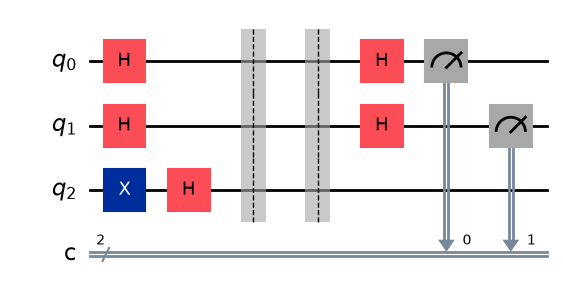

In [10]:
# Example 1: Deutsch-Jozsa Constant Oracle (Row 0)
draw_circuit(0)


### 🔮 Row Index `38` — Quantum Circuit Metadata

| Parameter | Value |
| :--- | :--- |
| **Algorithm** | `deutsch_jozsa` |
| **Qubits** | `2` |
| **Oracle** | `balanced_0` |
| **Depth** | `7` |
| **Gate Counts** | Total: `10` (1Q: `8`, 2Q: `2`) |
| **Noise Model** | `depolarizing` (p=0.005) |
| **Success Prob** | `0.9941` |


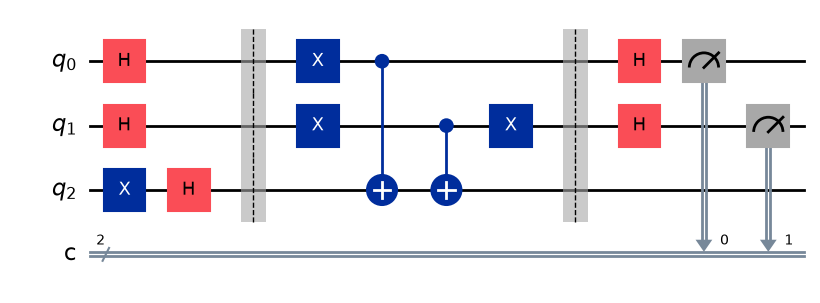

In [11]:
# Example 2: Deutsch-Jozsa Balanced Oracle (Row 38)
draw_circuit(38)


### 🔮 Row Index `216` — Quantum Circuit Metadata

| Parameter | Value |
| :--- | :--- |
| **Algorithm** | `deutsch_jozsa` |
| **Qubits** | `3` |
| **Oracle** | `constant_1` |
| **Depth** | `4` |
| **Gate Counts** | Total: `8` (1Q: `8`, 2Q: `0`) |
| **Noise Model** | `none` (p=0.0) |
| **Success Prob** | `1.0000` |


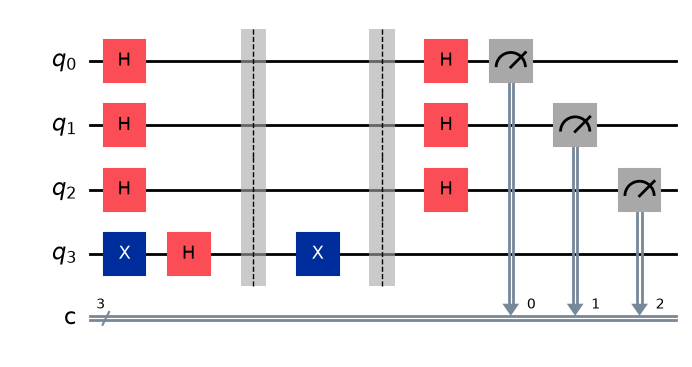

In [12]:
# Example 3: Bernstein-Vazirani Secret Bitstring (Row 216)
draw_circuit(216)


### 🔮 Row Index `432` — Quantum Circuit Metadata

| Parameter | Value |
| :--- | :--- |
| **Algorithm** | `deutsch_jozsa` |
| **Qubits** | `4` |
| **Oracle** | `balanced_0` |
| **Depth** | `8` |
| **Gate Counts** | Total: `16` (1Q: `12`, 2Q: `4`) |
| **Noise Model** | `none` (p=0.0) |
| **Success Prob** | `1.0000` |


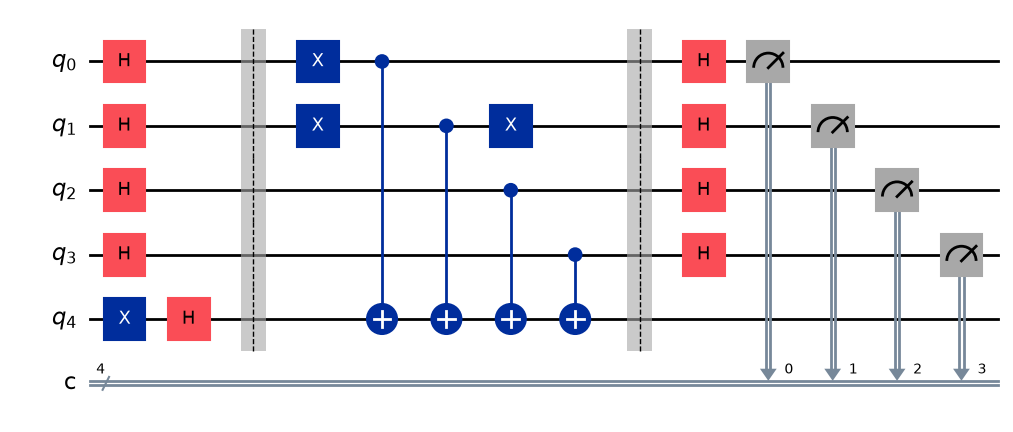

In [13]:
# Example 4: Simon's Algorithm Hidden Period (Row 432)
draw_circuit(432)